# Tumor subset only - clustering and manually annotating the scVIVA model of the ULMS G4X dataset
- annotates the tumor subset of the scVIVA_2 clustered object (proseg). The one with the reduced learning rate.
- This is for the revision of the paper.

In [1]:
import os
import sys
import numpy as np
import scanpy as sc
import torch
import scvi
import pandas as pd
import anndata as ad
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

module_path = '/labs/delitto/james/functions/'
sys.path.append(module_path)
import jpascvi

/home/jpagolia/miniforge3/envs/scvi-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# version control
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scanpy:", sc.__version__)
print("scvi:", scvi.__version__)

plt.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['pdf.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
mpl.rcParams['ps.fonttype'] = 42 # TrueType font for editing in Adobe Illustrator
plt.interactive = False
plt.ioff()
sc.settings.autoshow = False
plt.rcParams['savefig.dpi'] = 300
sc.set_figure_params(dpi_save=300, facecolor='white')

sc.settings.n_jobs = -1  # Use all available cores
SEED = 1234
scvi.settings.seed = SEED
torch.set_float32_matmul_precision("high")

[rank: 0] Seed set to 1234


pandas: 2.3.1
numpy: 2.2.6
scanpy: 1.11.4
scvi: 1.3.3


In [3]:
CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent
print(PARENT_DIR)

# Making an output directory using the pathlib package
output_dir = jpascvi.create_output_dir(PARENT_DIR, 'scviva_tumor', change_dir=True)

data_dir = PARENT_DIR / 'annotation'
print(data_dir)

/oak/stanford/groups/longaker/ULMS/revision/G4X
Created output directory /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_tumor
Working directory and scanpy figure output directory changed to /oak/stanford/groups/longaker/ULMS/revision/G4X/scviva_tumor
/oak/stanford/groups/longaker/ULMS/revision/G4X/annotation


# Clustering

In [ ]:
jpa_markers = jpascvi.import_markers((PARENT_DIR / 'ref/jpa_g4x_breast_panel.csv'), output_type='dict')
jpa_markers = {key: value for key, value in jpa_markers.items() if key != 'Plasma_cell'} # JCHAIN and IGHG1 not in this segmentation run
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
               1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

In [ ]:
adata = sc.read_h5ad(data_dir / 'scviva_celltype.h5ad')
adata

In [ ]:
cols_to_drop = ['_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 
                'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 
                'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 
                'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5']
adata.obs.drop(cols_to_drop, axis='columns', inplace=True, errors='ignore')

uns_to_drop = ['_scvi_manager_uuid', '_scvi_uuid', 
               'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 
               'dendrogram_leiden0_5', 'dendrogram_leiden0_6', 'dendrogram_leiden0_7', 'dendrogram_leiden0_8', 
               'dendrogram_leiden0_9', 'dendrogram_leiden1_0', 'dendrogram_leiden1_1', 'dendrogram_leiden1_2', 
               'dendrogram_leiden1_3', 'dendrogram_leiden1_4', 'dendrogram_leiden1_5', 
               'leiden0_1', 'leiden0_1_colors', 'leiden0_2', 'leiden0_2_colors', 'leiden0_3', 'leiden0_3_colors', 
               'leiden0_4', 'leiden0_4_colors', 'leiden0_5', 'leiden0_5_colors', 'leiden0_6', 'leiden0_6_colors', 
               'leiden0_7', 'leiden0_7_colors', 'leiden0_8', 'leiden0_8_colors', 'leiden0_9', 'leiden0_9_colors', 
               'leiden1_0', 'leiden1_0_colors', 'leiden1_1', 'leiden1_1_colors', 'leiden1_2', 'leiden1_2_colors', 
               'leiden1_3', 'leiden1_3_colors', 'leiden1_4', 'leiden1_4_colors', 'leiden1_5', 'leiden1_5_colors', 
               'log1p', 'neighbors', 'rank_genes_groups', 'umap']
for key in uns_to_drop:
    if key in adata.uns:
        adata.uns.pop(key, None)
    
del adata.obsp['connectivities']
del adata.obsp['distances']
del adata.obsm['X_umap']

print(adata)

In [ ]:
# subset for tumor cells
adata = adata[adata.obs['celltype'] == 'Tumor'].copy()
print(np.unique(adata.obs['celltype']))
print(adata)

In [ ]:
print('Calculating neighbors')
sc.pp.neighbors(adata, use_rep="X_scVIVA", n_neighbors=30)
print('Calculating UMAP')
sc.tl.umap(adata, min_dist=0.3)

In [ ]:
sc.pl.umap(adata, color='coarse_celltype', frameon=False, save='coarse_celltype.png')
sc.pl.umap(adata, color=['Section', 'Patient'], frameon=False, save='section_and_patient.png')
sc.pl.umap(adata, color=['component', 'volume', 'surface_area', 
                         'n_genes_by_counts', 'log1p_n_genes_by_counts', 
                         'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes',], 
           frameon=False, save='qc.png')

In [ ]:
jpascvi.featureplot(adata, jpa_markers, save='scviva.png', use_raw=False, vmax='p98') # False to allow scaled values to be plotted from adata.X

In [ ]:
# Leiden clustering at multiple resolutions and differential gene expression
for resolution in resolutions:
    str_res = str(resolution).replace('.', '_')
    leiden_key = 'leiden' + str_res
    sc.tl.leiden(adata, flavor="igraph", n_iterations=2, resolution=resolution, key_added=leiden_key)
    jpascvi.plot_umap(adata, resolution)
    jpascvi.sc_degs(adata, resolution, use_rep='X_scVIVA', plots=['dotplot'])

# Calculate clustering statistics to see which is the optimal resolution from a mathematical perspective
jpascvi.cluster_stats(adata, resolutions, scores = ['Calinski-Harabasz', 'Davies-Bouldin'], rep='X_scVIVA')

In [ ]:
adata.write_h5ad('scviva_tumor_clustered.h5ad')

In [ ]:
sc.pl.umap(adata, 
           color=['MYH11', 'MYLK', 'DES', 'TAGLN', 'ESR1', 'COL1A1', 'SDC1', 'SOX10'], 
           size=0.2, 
           save='ulms_feature_plot.png', 
           vmax='p98')

sc.pl.umap(adata, 
           color=['VEGFA', 'SLC2A1',], 
           size=0.2, 
           save='ischemia_feature_plot.png', 
           vmax='p98')

sc.pl.umap(adata, 
           color=['VWF', 'PECAM1', 'COL1A1', 'LUM', 'CD68', 'CD163', 'RGS5', 'PDGFRB', 'CD2', 'IL7R'], 
           size=0.2, 
           save='nontumor_feature_plot.png', 
           vmax='p98')

sc.pl.umap(adata, 
           color=['ESR1', 'PGR', 'AR'], 
           save='hormononal_feature_plot.png', 
           size=0.2, 
           vmax='p98')

sc.pl.umap(adata, 
           color=['LAG3', 'PDCD1'], 
           save='immune_checkpoint_feature_plot.png', 
           size=0.2, 
           vmax='p98')

In [ ]:
sc.pl.umap(adata, 
           color=['MYH11', 'MYLK', 'DES', 'TAGLN', 'ESR1', 'COL1A1', 'SDC1', 'SOX10'], 
           size=0.2, 
           save='ulms_feature_plot_corr.png', 
           vmax='p98',
           layer='generated_expression'
          )

sc.pl.umap(adata, 
           color=['VEGFA', 'SLC2A1',], 
           size=0.2, 
           save='ischemia_feature_plot_corr.png', 
           vmax='p98',
           layer='generated_expression'
          )

sc.pl.umap(adata, 
           color=['VWF', 'PECAM1', 'COL1A1', 'LUM', 'CD68', 'CD163', 'RGS5', 'PDGFRB', 'CD2', 'IL7R'], 
           size=0.2, 
           save='nontumor_feature_plot_corr.png', 
           vmax='p98',
           layer='generated_expression'
          )

sc.pl.umap(adata, 
           color=['ESR1', 'PGR', 'AR'], 
           save='hormononal_feature_plot_corr.png', 
           size=0.2, 
           vmax='p98',
           layer='generated_expression'
          )

sc.pl.umap(adata, 
           color=['LAG3', 'PDCD1'], 
           save='immune_checkpoint_feature_plot_corr.png', 
           size=0.2, 
           vmax='p98',
           layer='generated_expression'
          )

In [ ]:
sc.pl.umap(adata, 
           color=['MYH11', 'MYLK', 'DES', 'TAGLN', 'ESR1', 'COL1A1', 'SDC1', 'SOX10'], 
           size=0.2, 
           save='ulms_feature_plot_norm.png', 
           vmax='p98',
           layer='X_normalized_resolVI'
          )

sc.pl.umap(adata, 
           color=['VEGFA', 'SLC2A1',], 
           size=0.2, 
           save='ischemia_feature_plot_norm.png', 
           vmax='p98',
           layer='X_normalized_resolVI'
          )

sc.pl.umap(adata, 
           color=['VWF', 'PECAM1', 'COL1A1', 'LUM', 'CD68', 'CD163', 'RGS5', 'PDGFRB', 'CD2', 'IL7R'], 
           size=0.2, 
           save='nontumor_feature_plot_norm.png', 
           vmax='p98',
           layer='X_normalized_resolVI'
          )

sc.pl.umap(adata, 
           color=['ESR1', 'PGR', 'AR'], 
           save='hormononal_feature_plot_norm.png', 
           size=0.2, 
           vmax='p98',
           layer='X_normalized_resolVI'
          )

sc.pl.umap(adata, 
           color=['LAG3', 'PDCD1'], 
           save='immune_checkpoint_feature_plot_norm.png', 
           size=0.2, 
           vmax='p98',
           layer='X_normalized_resolVI'
          )

# Manual annotation

In [4]:
tumor = sc.read_h5ad(output_dir / 'scviva_tumor_clustered.h5ad')
tumor

AnnData object with n_obs × n_vars = 1561027 × 304
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'Section', 'cell_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_genes', 'Patient', 'true_proportion', 'diffusion_proportion', 'background_proportion', 'coarse_celltype', 'index', '_scvi_sample', 'scviva_coarse_ct', 'celltype', 'ann_leiden', 'leiden0_1', 'leiden0_2', 'leiden0_3', 'leiden0_4', 'leiden0_5', 'leiden0_6', 'leiden0_7', 'leiden0_8', 'leiden0_9', 'leiden1_0', 'leiden1_1', 'leiden1_2', 'leiden1_3', 'leiden1_4', 'leiden1_5', 'leiden1_6', 'leiden1_7', 'leiden1_8', 'leiden1_9', 'leiden2_0'
    var: 'mean', 'std'
    uns: 'Patient_colors', 'Section_colors', 'ann_leiden_colors', 'celltype_colors', 'coarse_celltype_colors', 'dendrogram_leiden0_1', 'dendrogram_leiden0_2', 'dendrogram_leiden0_3', 'dendrogram_leiden0_4', 'dendrogram_leiden0_5', 'dendro

In [ ]:
gene = 'ESR1'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'PGR'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'AR'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
gene = 'MYH11'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'TAGLN'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'CD44'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'RSPO3'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

gene = 'STAT3'
umap = sc.pl.umap(tumor, color=gene, color_map='inferno', frameon=False, show=False, return_fig=True, title=gene, size=0.5)
umap.set_size_inches(5, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig(f'{gene}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{gene}.png', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
all_genes = tumor.var_names.to_list()
print(all_genes)

In [ ]:
sc.pl.dotplot(tumor, 
              var_names=all_genes, 
              groupby='leiden0_8', 
              dendrogram=False, 
              standard_scale='var',
              save='leiden0_8_all_genes.png'
             )

In [ ]:
leiden_key = 'leiden0_8'
sc.pl.umap(tumor, color=leiden_key, groups=['4'], palette=['red'], na_color='white')

In [ ]:
leiden_key = 'leiden0_8'
markers = [
    'ESR1', 'PGR', 'AR', 'RSPO3', 'CCND1', 'CD44',
    'MYH11', 'TAGLN', 'ACTA2', 'ACTG2', 'MYLK', 'A2M',
    'TNC', 'DST', 'FLNB', 'SYNM',
    'CHI3L1', 'NCAM1',
    'THBS2', 'PFN2',
    'HLA-DRA', 'CD74', 'CD68', 'CD163', 'WARS1', 'STAT1',
    'VEGFA', 'SLC2A1',
    'COL1A1', 'POSTN',
    'SDC1', 'PDGFRB', 'EGFR', 'CD9',
    'MKI67', 'TOP2A', 'RRM2'
]
sc.pl.dotplot(tumor, 
              var_names=markers, 
              groupby=leiden_key, 
              dendrogram=False, 
              standard_scale='var', 
              save=f'{leiden_key}_full_ann_dotplot.png'
             )
sc.pl.dotplot(tumor, 
              var_names=markers, 
              groupby=leiden_key, 
              dendrogram=False, 
              standard_scale='var', 
              use_raw=False, 
              save=f'{leiden_key}_full_ann_dotplot_scaled.png'
             )
sc.pl.dotplot(tumor, 
              var_names=markers, 
              groupby=leiden_key, 
              dendrogram=False, 
              standard_scale='var', 
              layer='X_normalized_resolVI', 
              save=f'{leiden_key}_full_ann_dotplot_norm.png',
              expression_cutoff=0.001
             )
sc.pl.dotplot(tumor, 
              var_names=markers, 
              groupby=leiden_key, 
              dendrogram=False, 
              standard_scale='var', 
              layer='generated_expression', 
              save=f'{leiden_key}_full_ann_dotplot_corr.png',
              expression_cutoff=0.1
             )

In [ ]:
# annotate
leiden_key = 'leiden0_8'
leiden_map = {
    '0' : 'CHI3L1-low SMC-like Tumor',
    '1' : 'CHI3L1-low SMC-like Tumor',
    '2' : 'CHI3L1-high SMC-like Tumor',
    '3' : 'IFN Signaling Tumor',
    '4' : 'ESR1 PGR AR Tumor',
    '5' : 'CHI3L1-high SMC-like Tumor',
    '6' : 'CHI3L1-low SMC-like Tumor',
    '7' : 'CHI3L1-low SMC-like Tumor',
    '8' : 'Cycling COL1A1 POSTN Tumor',
    '9' : 'Cycling IFN Signaling Tumor',
    '10' : 'IFN Signaling Tumor',
    '11' : 'Ischemic Tumor',
    '12' : 'CHI3L1-low SMC-like Tumor',
    '13' : 'CHI3L1-low SMC-like Tumor',
    '14' : 'SDC1 PDGFRB Tumor',
    '15' : 'COL1A1 POSTN Tumor',
    '16' : 'Cycling SMC-low Tumor',
}
tumor.obs['tumor_subtype'] = tumor.obs[leiden_key].map(leiden_map)
tumor.obs['tumor_subtype']

In [ ]:
np.unique(tumor.obs['tumor_subtype'])

In [ ]:
subtype_dict = {
    "ESR1 PGR AR Tumor" : "#008080",
    "CHI3L1-high SMC-like Tumor" : "#BE469A",
    "CHI3L1-low SMC-like Tumor" : "#E892CE",
    "Ischemic Tumor" : "#9168AB",
    "IFN Signaling Tumor" : "#D52927",
    "Cycling IFN Signaling Tumor" : "#5E3D36",
    "Cycling SMC-low Tumor" : "#8E5C52",
    "Cycling COL1A1 POSTN Tumor" : "#AD8981",
    "COL1A1 POSTN Tumor" : "#ED7015",
    "SDC1 PDGFRB Tumor" : "#FCAE1F",
}

In [ ]:
assert set(np.unique(tumor.obs['tumor_subtype'])) == set(subtype_dict)
tumor.obs['tumor_subtype'] = pd.Categorical(tumor.obs['tumor_subtype'], ordered=True, categories=list(subtype_dict))
print(tumor.obs['tumor_subtype'])
tumor.uns['tumor_subtype_colors'] = list(subtype_dict.values())
print(tumor.uns['tumor_subtype_colors'])

In [ ]:
sc.pl.umap(tumor, color='tumor_subtype', save='scviva_tumor_subtype.png', frameon=False)
sc.pl.umap(tumor, color='tumor_subtype', save='scviva_tumor_subtype.pdf', frameon=False)

In [ ]:
markers = [
    'ESR1', 'PGR', 'AR',
    'CHI3L1', 'NCAM1',
    'MYH11', 'TAGLN', 'ACTA2', 'MYLK',
    'VEGFA', 'SLC2A1',
    'HLA-DRA', 'CD74', 'WARS1', 'STAT1',
    'MKI67', 'TOP2A', 'RRM2',
    'COL1A1', 'POSTN',
    'SDC1', 'PDGFRB',
]
sc.pl.dotplot(tumor, var_names=markers, groupby='tumor_subtype', dendrogram=False, standard_scale='var', save='ann_dp.png')
sc.pl.dotplot(tumor, var_names=markers, groupby='tumor_subtype', dendrogram=False, standard_scale='var', save='ann_dp.pdf')

In [ ]:
tumor.write_h5ad(output_dir / 'tumor_annotated.h5ad')

In [10]:
# Dotplot of top 10 DEGS in cluster 4
str_res = '0_8'
leiden_key = 'leiden' + str_res
print(f"Calculating scanpy DEGs for {leiden_key}")
sc.tl.rank_genes_groups(tumor, groupby=leiden_key, method="wilcoxon")
rank_genes_filename = f'{str_res}_sc_top_genes_review.png'
sc.pl.rank_genes_groups_dotplot(tumor, groupby=leiden_key, standard_scale="var", n_genes=10, save=rank_genes_filename)

Calculating scanpy DEGs for leiden0_8


{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

In [11]:
cluster = '4'
rank_genes_filename = f'{str_res}_sc_top_genes_cluster{cluster}.png'
sc.pl.rank_genes_groups_dotplot(tumor, groupby=leiden_key, groups=cluster, standard_scale="var", n_genes=10, save=rank_genes_filename)

categories: 0, 1, 2, etc.
var_group_labels: 4


{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

categories: 0, 1, 2, etc.
var_group_labels: 4


{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'log fold change'}>}

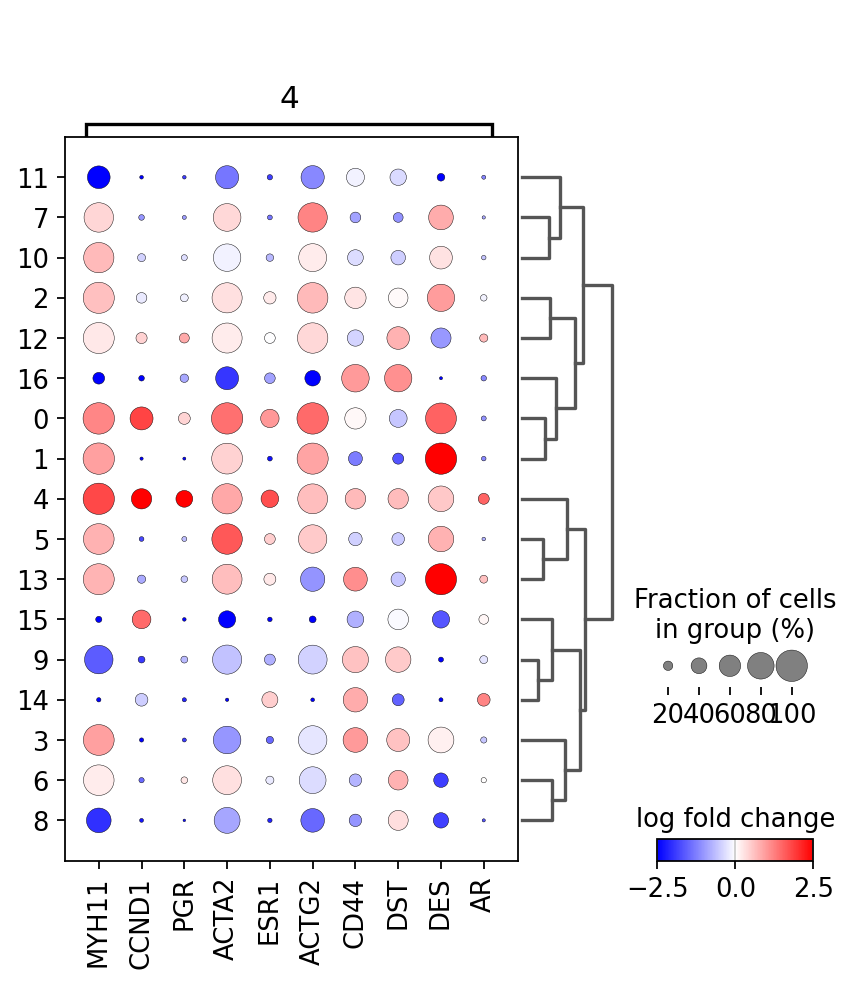

In [14]:
sc.pl.rank_genes_groups_dotplot(
    tumor,
    n_genes=10,
    groups=cluster,
    values_to_plot="logfoldchanges", cmap='bwr',
    vmin=-2.5,
    vmax=2.5,
    min_logfoldchange=0.5,
    colorbar_title='log fold change'
)

# Bar plots

In [ ]:
tumor = sc.read_h5ad(output_dir / 'tumor_annotated.h5ad')
tumor

In [ ]:
# order sections properly. This is how they will print on the page.
sections = [
    'B01', 'C01', 'D01', 'E01', 
    'F01', 'G01', 'H01', 'A02', 
    'B02', 'C02', 'E02', 'F02', 
    'G02', 'H02', 'A03', 'B03', 
    'C03', 'D03', 'E03', 'F03', 
    'G03', 'H03', 'A04', 'B04', 
    'C04', 'D04',
]

In [ ]:
tumor.obs['tumor_subtype'].cat.categories.to_list()

In [ ]:
# Making section barplot of tumor subtypes

# Create a color mapping
tumor_subtype_order = tumor.obs['tumor_subtype'].cat.categories.to_list()
tumor_subtype_colors = tumor.uns['tumor_subtype_colors']
color_mapping = {tumor_subtype: tumor_subtype_colors[i] 
                 for i, tumor_subtype in enumerate(tumor_subtype_order)}
print("Color Mapping from adata.uns:", color_mapping)

# Get the counts of each tumor subtype in each section
grouped = tumor.obs.groupby('Section', observed=True)['tumor_subtype'].value_counts()
# Create a data frame from the grouped series
df = grouped.reset_index(name='count')
# Get the totals per section
total = df.groupby('Section', observed=True)['count'].sum().reset_index(name='total')
df = pd.merge(df, total, on='Section')
# Calculate the percentages
df['percentage'] = (df['count'] / df['total']) * 100
# Pivot to wide format for stacked bar plot
df_pivot = df.pivot(index='Section', columns='tumor_subtype', values='percentage')
# Reorder columns to match desired tumor subtype order
df_pivot = df_pivot[tumor_subtype_order] # column order
df_pivot = df_pivot.reindex(sections[::-1])  # row order (custom section order)
df_pivot = df_pivot.fillna(0)  # handle missing combinations

# Ensure the colors are in the correct order
ordered_colors = [color_mapping[t] for t in df_pivot.columns]
print("Ordered Colors for Bar Plot:", ordered_colors)

# Make plot
fig, ax = plt.subplots(figsize=(8, 8))
df_pivot.plot(
    kind='barh',
    stacked=True,
    width=0.9,
    color=ordered_colors,
    ax=ax
)
ax.set_title('Tumor Subtypes in Each Section')
ax.set_xlabel('Percentage (%)')
ax.grid(False)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tumor Subtype')
# Or remove legend:
# ax.get_legend().remove()

plt.tight_layout()
png_path = output_dir / 'subtypes_only_bysection_barplot.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
pdf_path = output_dir / 'subtypes_only_bysection_barplot.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
tumor.obs['Patient']

In [ ]:
tumor.obs['Patient'].cat.categories

In [ ]:
# G4X patient to scRNAseq patient mapping
patient_map = {
    '1'	: '01',
    '2'	: '02',
    '3'	: '03',
    '4'	: '04',
    '5'	: '06',
    '6'	: '07',
    '7'	: '08',
    '8'	: '09',
    '9'	: '10',
}
tumor.obs['Sample'] = tumor.obs['Patient'].map(patient_map)

In [ ]:
# Making sample barplot of tumor subtypes
# Use the same color mapping from above
print("Color Mapping from adata.uns:", color_mapping)

# Get the counts of each tumor subtype in each sample
grouped = tumor.obs.groupby('Sample', observed=True)['tumor_subtype'].value_counts()
# Create a data frame from the grouped series
df = grouped.reset_index(name='count')
# Get the totals per sample
total = df.groupby('Sample', observed=True)['count'].sum().reset_index(name='total')
df = pd.merge(df, total, on='Sample')
# Calculate the percentages
df['percentage'] = (df['count'] / df['total']) * 100
# Pivot to wide format for stacked bar plot
df_pivot = df.pivot(index='Sample', columns='tumor_subtype', values='percentage')
# Reorder columns to match desired tumor subtype order
df_pivot = df_pivot[tumor_subtype_order] # column order
df_pivot = df_pivot.sort_index(ascending=False)
df_pivot = df_pivot.fillna(0)  # handle missing combinations

# Ensure the colors are in the correct order
ordered_colors = [color_mapping[t] for t in df_pivot.columns]
print("Ordered Colors for Bar Plot:", ordered_colors)

# Make plot
fig, ax = plt.subplots(figsize=(8, 8))
df_pivot.plot(
    kind='barh',
    stacked=True,
    width=0.9,
    color=ordered_colors,
    ax=ax
)
ax.set_title('Tumor Subtypes in Each Sample')
ax.set_xlabel('Percentage (%)')
ax.grid(False)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tumor Subtype')
# Or remove legend:
# ax.get_legend().remove()

plt.tight_layout()
png_path = output_dir / 'subtypes_only_bysample_barplot.png'
plt.savefig(png_path, dpi=300, bbox_inches='tight')
pdf_path = output_dir / 'subtypes_only_bysample_barplot.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches='tight')
plt.close()

# Looking at the ESR PGR AR and CHI3L1-high tumor cells

In [ ]:
umap = sc.pl.umap(tumor, color='tumor_subtype', frameon=False, show=False, return_fig=True, title='', size=0.2)
umap.set_size_inches(7, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('tumor.png', dpi=300, bbox_inches='tight')
plt.savefig('tumor.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
umap = sc.pl.umap(tumor, color='tumor_subtype', groups='ESR1 PGR AR Tumor', frameon=False, show=False, return_fig=True, title='', size=0.5)
umap.set_size_inches(7, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('esr_pgr_highlight.png', dpi=300, bbox_inches='tight')
plt.savefig('esr_pgr_highlight.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# hide the legend
umap = sc.pl.umap(tumor, color='tumor_subtype', groups='ESR1 PGR AR Tumor', frameon=False, show=False, return_fig=True, title='', size=0.5)
umap.set_size_inches(5, 4)
plt.legend('', frameon=False) # Remove the legend
plt.tight_layout()
plt.savefig('esr_pgr_highlight_nolegend.png', dpi=300, bbox_inches='tight')
plt.savefig('esr_pgr_highlight_nolegend.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
umap = sc.pl.umap(tumor, color='tumor_subtype', groups=['ESR1 PGR AR Tumor', 'CHI3L1-high SMC-like Tumor'], frameon=False, show=False, return_fig=True, title='', size=0.5)
umap.set_size_inches(7, 4)
plt.legend(ncol=1, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('esr_pgr_and_chi3l1_highlight.png', dpi=300, bbox_inches='tight')
plt.savefig('esr_pgr_and_chi3l1_highlight.pdf', dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
# hide the legend
umap = sc.pl.umap(tumor, color='tumor_subtype', groups=['ESR1 PGR AR Tumor', 'CHI3L1-high SMC-like Tumor'], frameon=False, show=False, return_fig=True, title='', size=0.5)
umap.set_size_inches(5, 4)
plt.legend('', frameon=False) # Remove the legend
plt.tight_layout()
plt.savefig('esr_pgr_and_chi3l1_highlight_nolegend.png', dpi=300, bbox_inches='tight')
plt.savefig('esr_pgr_and_chi3l1_highlight_nolegend.pdf', dpi=300, bbox_inches='tight')
plt.close()